# LSTM

## Daily Log Return

In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
from abc import ABC, abstractmethod

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X, y):
        pass

    @abstractmethod
    def save(self, path: str):
        pass

    @abstractmethod
    def load(self, path: str):
        pass

In [3]:
def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    return float(np.mean(np.sign(y) == np.sign(yhat)))

In [4]:
def build_sequence_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    # --- Load macro ---
    df_macro = pd.read_csv(macro_file, skiprows=[1]).rename(columns={"sasdate": "date"})
    df_macro["date"] = pd.to_datetime(df_macro["date"])
    df_macro = df_macro.set_index("date").sort_index()

    # Anti-leakage shift
    df_macro.index = df_macro.index + pd.offsets.MonthBegin(1)

    # --- Load price ---
    df_price = pd.read_csv(price_file, parse_dates=["Date"])
    df_price = df_price.set_index("Date")["Price"].sort_index()

    # Align macro to trading days
    df_macro = df_macro.reindex(df_price.index, method="ffill")

    df = df_macro[features].join(df_price).dropna()

    # Add daily return
    df["ret_1d"] = np.log(df["Price"]).diff()
    df = df.dropna()

    # Target
    y = (np.log(df["Price"].shift(-horizon)) - np.log(df["Price"])).rename("y")

    df = df.drop(columns=["Price"])

    df = df.loc[y.index]
    valid = y.notna()
    df = df[valid]
    y = y[valid]

    # --- Build sequences ---
    X_sequences = []
    y_out = []

    values = df.values
    target = y.values

    max_idx = min(len(df), len(target))

    for i in range(lookback, max_idx):
        X_sequences.append(values[i - lookback:i])
        y_out.append(target[i])

    X_sequences = np.array(X_sequences)
    y_out = np.array(y_out)

    dates = df.index[lookback: len(df) - horizon + 1]

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_idx = dates <= train_end
    val_idx = (dates > train_end) & (dates <= val_end)
    test_idx = dates > val_end

    return (
        X_sequences[train_idx], y_out[train_idx],
        X_sequences[val_idx],   y_out[val_idx],
        X_sequences[test_idx],  y_out[test_idx],
    )

In [5]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
class LSTMNetDeep(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.norm = nn.LayerNorm(hidden_size)

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.norm(out)
        return self.head(out).squeeze()

In [7]:
class LSTMForecastModel(BaseForecastModel):

    def __init__(
        self,
        epochs=80,
        batch_size=64,
        lr=5e-4,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        weight_decay=1e-5,
        patience=15,
        device=None
    ):
        super().__init__("regression")

        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.weight_decay = weight_decay
        self.patience = patience

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print("Using device:", self.device)

        self.scaler = StandardScaler()
        self.model = None


    def fit(self, X_train, y_train, X_val, y_val):

        N, T, F = X_train.shape

        # -------- SCALE --------
        X_train_2d = X_train.reshape(-1, F)
        self.scaler.fit(X_train_2d)

        def scale(X):
            X2d = X.reshape(-1, F)
            X_scaled = self.scaler.transform(X2d)
            return X_scaled.reshape(X.shape)

        X_train = scale(X_train)
        X_val = scale(X_val)

        train_loader = DataLoader(
            SequenceDataset(X_train, y_train),
            batch_size=self.batch_size,
            shuffle=False
        )

        val_loader = DataLoader(
            SequenceDataset(X_val, y_val),
            batch_size=self.batch_size,
            shuffle=False
        )

        self.model = LSTMNetDeep(
            input_size=F,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=self.dropout
        ).to(self.device)

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )

        criterion = nn.MSELoss()

        best_val = np.inf
        patience_counter = 0

        for epoch in range(self.epochs):

            self.model.train()

            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                optimizer.zero_grad()
                preds = self.model(xb)
                loss = criterion(preds, yb)
                loss.backward()

                # -------- GRADIENT CLIPPING --------
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

                optimizer.step()

            # -------- VALIDATION --------
            self.model.eval()
            val_preds = []
            val_true = []

            with torch.no_grad():
                for xb, yb in val_loader:
                    xb = xb.to(self.device)
                    preds = self.model(xb).cpu().numpy()
                    val_preds.append(preds)
                    val_true.append(yb.numpy())

            val_preds = np.concatenate(val_preds)
            val_true = np.concatenate(val_true)

            val_rmse = rmse(val_true, val_preds)

            print(f"Epoch {epoch+1} | Val RMSE: {val_rmse:.6f}")

            if val_rmse < best_val:
                best_val = val_rmse
                best_state = self.model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping triggered")
                    break

        self.model.load_state_dict(best_state)
        return self


    def predict(self, X):
        N, T, F = X.shape
        X2d = X.reshape(-1, F)
        X_scaled = self.scaler.transform(X2d).reshape(X.shape)

        loader = DataLoader(
            SequenceDataset(X_scaled, np.zeros(len(X))),
            batch_size=self.batch_size,
            shuffle=False
        )

        self.model.eval()
        preds = []

        with torch.no_grad():
            for xb, _ in loader:
                xb = xb.to(self.device)
                preds.append(self.model(xb).cpu().numpy())

        return np.concatenate(preds)


    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y, p),
            "mae": mae(y, p),
            "r2": r2(y, p),
            "directional_acc": directional_accuracy(y, p),
        }


    def save(self, path):
        torch.save({
            "model_state": self.model.state_dict(),
            "scaler": self.scaler,
        }, path)


    def load(self, path):
        checkpoint = torch.load(path)
        self.model.load_state_dict(checkpoint["model_state"])
        self.scaler = checkpoint["scaler"]

In [8]:
if __name__ == "__main__":

    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    Xtr, ytr, Xva, yva, Xte, yte = build_sequence_dataset(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30,
        horizon=1
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    model = LSTMForecastModel()
    model.fit(Xtr, ytr, Xva, yva)

    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))

    model.save("lstm_wti_30d.pt")

Shapes: (7953, 30, 32) (2635, 30, 32) (215, 30, 32)
Using device: cpu
Epoch 1 | Val RMSE: 0.048698
Epoch 2 | Val RMSE: 0.033792
Epoch 3 | Val RMSE: 0.032454
Epoch 4 | Val RMSE: 0.032441
Epoch 5 | Val RMSE: 0.032758
Epoch 6 | Val RMSE: 0.032005
Epoch 7 | Val RMSE: 0.032078
Epoch 8 | Val RMSE: 0.032055
Epoch 9 | Val RMSE: 0.032119
Epoch 10 | Val RMSE: 0.032174
Epoch 11 | Val RMSE: 0.032277
Epoch 12 | Val RMSE: 0.032215
Epoch 13 | Val RMSE: 0.032431
Epoch 14 | Val RMSE: 0.032052
Epoch 15 | Val RMSE: 0.032016
Epoch 16 | Val RMSE: 0.032290
Epoch 17 | Val RMSE: 0.032216
Epoch 18 | Val RMSE: 0.032056
Epoch 19 | Val RMSE: 0.032265
Epoch 20 | Val RMSE: 0.032131
Epoch 21 | Val RMSE: 0.031774
Epoch 22 | Val RMSE: 0.031938
Epoch 23 | Val RMSE: 0.031936
Epoch 24 | Val RMSE: 0.032046
Epoch 25 | Val RMSE: 0.031845
Epoch 26 | Val RMSE: 0.031898
Epoch 27 | Val RMSE: 0.031796
Epoch 28 | Val RMSE: 0.031870
Epoch 29 | Val RMSE: 0.032481
Epoch 30 | Val RMSE: 0.031606
Epoch 31 | Val RMSE: 0.031281
Epoch 32 

In [22]:
print("Mean y_val:", np.mean(yva))
print("Std y_val:", np.std(yva))

Mean y_val: 0.00010788825363393628
Std y_val: 0.030870434230016605


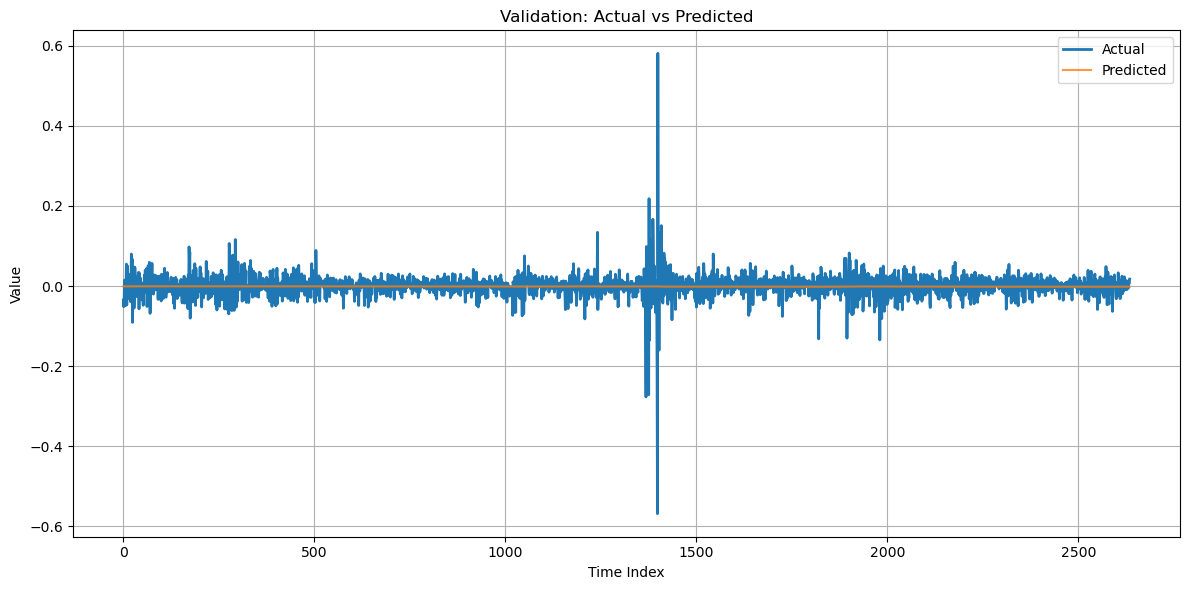

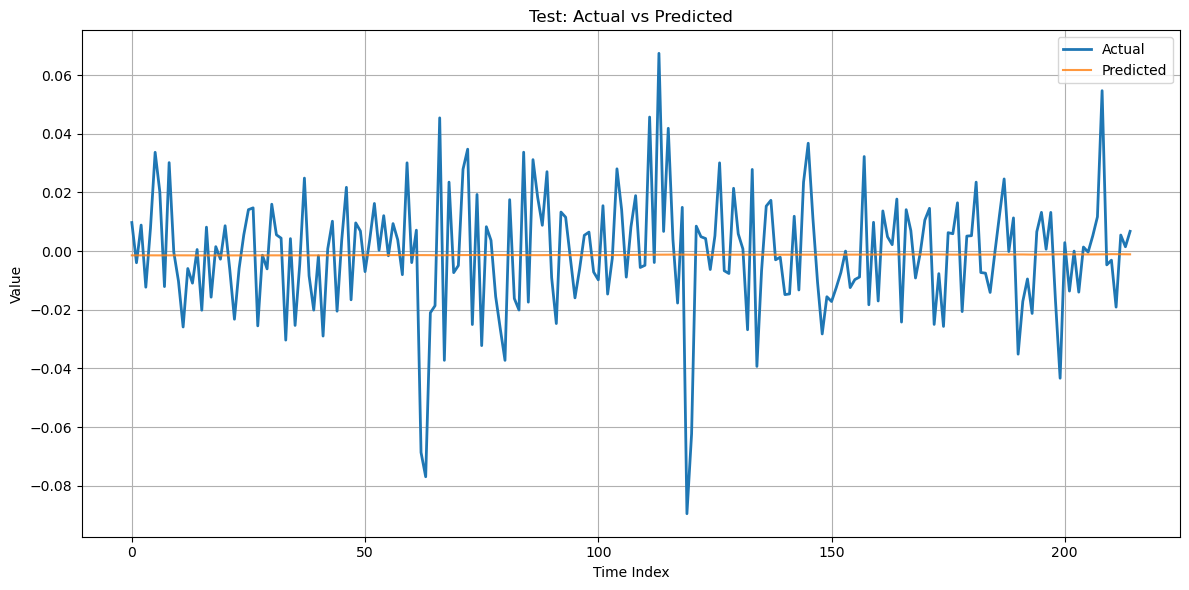

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted"):

    # Ensure numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", alpha=0.8)

    plt.title(title)
    plt.xlabel("Time Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

yhat_val = model.predict(Xva)
yhat_test = model.predict(Xte)

plot_actual_vs_pred(yva, yhat_val, "Validation: Actual vs Predicted")
plot_actual_vs_pred(yte, yhat_test, "Test: Actual vs Predicted")

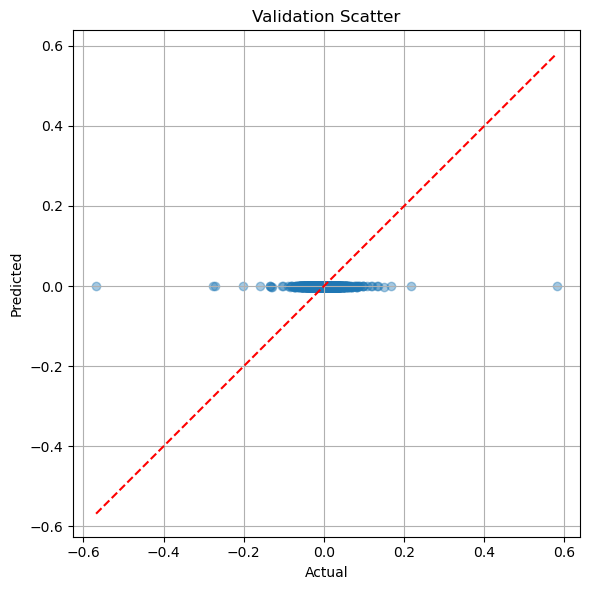

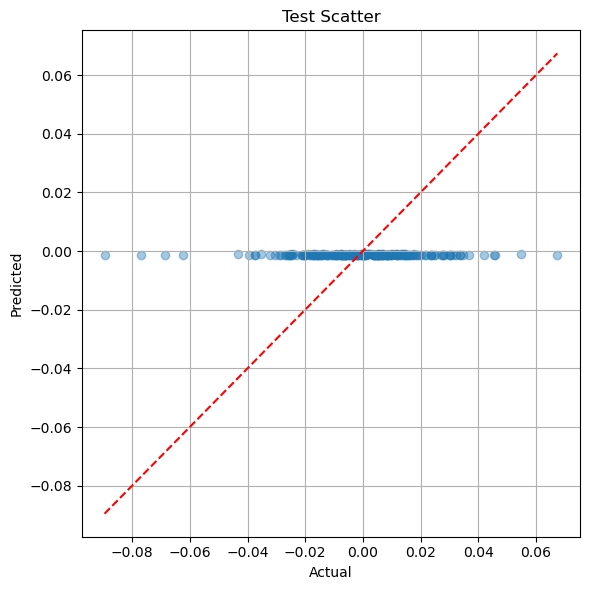

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scatter(y_true, y_pred, title="Predicted vs Actual"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.4)

    # 45-degree line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

yhat_val = model.predict(Xva)
yhat_test = model.predict(Xte)

plot_scatter(yva, yhat_val, "Validation Scatter")
plot_scatter(yte, yhat_test, "Test Scatter")

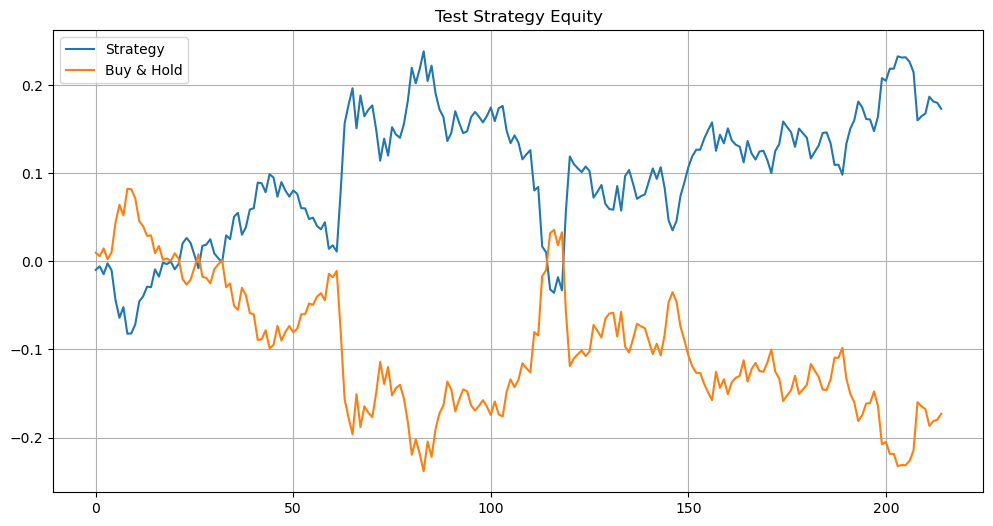

In [15]:
def plot_strategy_equity(y_true, y_pred, title="Strategy Equity Curve"):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert to sign strategy
    positions = np.sign(y_pred)

    # Strategy returns
    strategy_returns = positions * y_true

    # Cumulative returns
    cumulative_strategy = np.cumsum(strategy_returns)
    cumulative_buyhold = np.cumsum(y_true)

    plt.figure(figsize=(12,6))
    plt.plot(cumulative_strategy, label="Strategy")
    plt.plot(cumulative_buyhold, label="Buy & Hold")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_strategy_equity(yte, yhat_test, "Test Strategy Equity")

In [16]:
directional_acc = np.mean(np.sign(yhat_test) == np.sign(yte))
print("Directional Accuracy:", directional_acc)

strategy_returns = np.sign(yhat_test) * yte
sharpe = np.mean(strategy_returns) / np.std(strategy_returns)
print("Sharpe (daily):", sharpe)

print("Annualized Sharpe:", sharpe * np.sqrt(252))

Directional Accuracy: 0.49767441860465117
Sharpe (daily): 0.039254918671945464
Annualized Sharpe: 0.6231525152522016


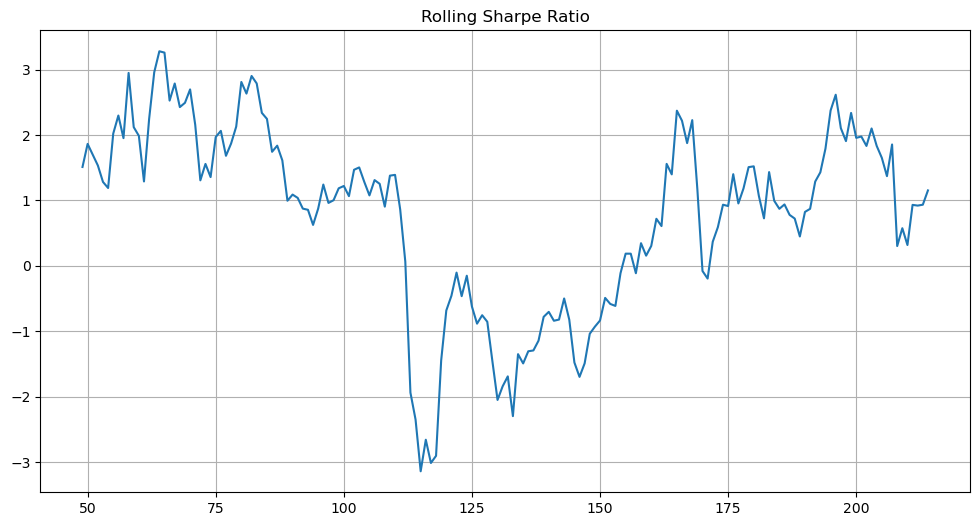

In [17]:
def plot_rolling_sharpe(y_true, y_pred, window=50):

    strategy_returns = np.sign(y_pred) * y_true

    rolling_mean = pd.Series(strategy_returns).rolling(window).mean()
    rolling_std = pd.Series(strategy_returns).rolling(window).std()

    rolling_sharpe = rolling_mean / rolling_std * np.sqrt(252)

    plt.figure(figsize=(12,6))
    plt.plot(rolling_sharpe)
    plt.title("Rolling Sharpe Ratio")
    plt.grid(True)
    plt.show()

plot_rolling_sharpe(yte, yhat_test, window=50)

## Volatility Prediction

In [18]:
class LSTMForecastModel(BaseForecastModel):

    def __init__(
        self,
        epochs=80,
        batch_size=64,
        lr=5e-4,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        weight_decay=1e-5,
        patience=15,
        device=None
    ):
        super().__init__("regression")

        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.weight_decay = weight_decay
        self.patience = patience

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print("Using device:", self.device)

        self.scaler = StandardScaler()
        self.model = None


    def fit(self, X_train, y_train, X_val, y_val):

        N, T, F = X_train.shape

        # -------- SCALE --------
        X_train_2d = X_train.reshape(-1, F)
        self.scaler.fit(X_train_2d)

        def scale(X):
            X2d = X.reshape(-1, F)
            X_scaled = self.scaler.transform(X2d)
            return X_scaled.reshape(X.shape)

        X_train = scale(X_train)
        X_val = scale(X_val)

        self.y_mean = y_train.mean()
        self.y_std = y_train.std()

        y_train_scaled = (y_train - self.y_mean) / self.y_std
        y_val_scaled = (y_val - self.y_mean) / self.y_std

        train_loader = DataLoader(
            SequenceDataset(X_train, y_train_scaled),
            batch_size=self.batch_size,
            shuffle=False
        )

        val_loader = DataLoader(
            SequenceDataset(X_val, y_val_scaled),
            batch_size=self.batch_size,
            shuffle=False
        )

        self.model = LSTMNetDeep(
            input_size=F,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=self.dropout
        ).to(self.device)

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )

        criterion = nn.MSELoss()

        best_val = np.inf
        patience_counter = 0

        for epoch in range(self.epochs):

            self.model.train()

            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                optimizer.zero_grad()
                preds = self.model(xb)
                loss = criterion(preds, yb)
                loss.backward()

                # -------- GRADIENT CLIPPING --------
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

                optimizer.step()

            # -------- VALIDATION --------
            self.model.eval()
            val_preds = []
            val_true = []

            with torch.no_grad():
                for xb, yb in val_loader:
                    xb = xb.to(self.device)
                    preds = self.model(xb).cpu().numpy()
                    val_preds.append(preds)
                    val_true.append(yb.numpy())

            val_preds = np.concatenate(val_preds)
            val_true = np.concatenate(val_true)

            val_rmse = rmse(val_true, val_preds)

            print(f"Epoch {epoch+1} | Val RMSE: {val_rmse:.6f}")

            if val_rmse < best_val:
                best_val = val_rmse
                best_state = self.model.state_dict()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping triggered")
                    break

        self.model.load_state_dict(best_state)
        return self


    def predict(self, X):
        N, T, F = X.shape
        X2d = X.reshape(-1, F)
        X_scaled = self.scaler.transform(X2d).reshape(X.shape)

        loader = DataLoader(
            SequenceDataset(X_scaled, np.zeros(len(X))),
            batch_size=self.batch_size,
            shuffle=False
        )

        self.model.eval()
        preds = []

        with torch.no_grad():
            for xb, _ in loader:
                xb = xb.to(self.device)
                preds.append(self.model(xb).cpu().numpy())

        preds = np.concatenate(preds)

        # -------- UN-SCALE TARGET --------
        preds = preds * self.y_std + self.y_mean

        return preds


    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y, p),
            "mae": mae(y, p),
            "r2": r2(y, p),
            "directional_acc": directional_accuracy(y, p),
        }


    def save(self, path):
        torch.save({
            "model_state": self.model.state_dict(),
            "scaler": self.scaler,
        }, path)


    def load(self, path):
        checkpoint = torch.load(path)
        self.model.load_state_dict(checkpoint["model_state"])
        self.scaler = checkpoint["scaler"]

In [33]:
def build_sequence_dataset_vol(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    # --- Load macro ---
    df_macro = pd.read_csv(macro_file, skiprows=[1]).rename(columns={"sasdate": "date"})
    df_macro["date"] = pd.to_datetime(df_macro["date"])
    df_macro = df_macro.set_index("date").sort_index()

    # Anti-leakage
    df_macro.index = df_macro.index + pd.offsets.MonthBegin(1)

    # --- Load price ---
    df_price = pd.read_csv(price_file, parse_dates=["Date"])
    df_price = df_price.set_index("Date")["Price"].sort_index()

    # Align macro to trading days
    df_macro = df_macro.reindex(df_price.index, method="ffill")

    df = df_macro[features].join(df_price).dropna()

    # Daily return
    df["ret_1d"] = np.log(df["Price"]).diff()
    df = df.dropna()

    # -------- VOLATILITY TARGET --------
    epsilon = 1e-8
    df["vol_target"] = np.log(df["ret_1d"].shift(-1) ** 2 + epsilon)

    y = df["vol_target"]
    df = df.drop(columns=["Price", "vol_target"])

    valid = y.notna()
    df = df[valid]
    y = y[valid]
    print(df)
    print(df['ret_1d'])

    values = df.values
    target = y.values

    X_sequences = []
    y_out = []

    for i in range(lookback, len(df)):
        X_sequences.append(values[i - lookback:i])
        y_out.append(target[i])

    X_sequences = np.array(X_sequences)
    y_out = np.array(y_out)

    dates = df.index[lookback:]

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_idx = dates <= train_end
    val_idx = (dates > train_end) & (dates <= val_end)
    test_idx = dates > val_end

    return (
        X_sequences[train_idx], y_out[train_idx],
        X_sequences[val_idx],   y_out[val_idx],
        X_sequences[test_idx],  y_out[test_idx],
    )

In [34]:
if __name__ == "__main__":

    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    Xtr, ytr, Xva, yva, Xte, yte = build_sequence_dataset_vol(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        lookback=30
    )

    print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)

    model = LSTMForecastModel(
        epochs=80,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        lr=5e-4,
        patience=15
    )

    model.fit(Xtr, ytr, Xva, yva)

    print("\nValidation:", model.evaluate(Xva, yva))
    print("\nTest:", model.evaluate(Xte, yte))

    model.save("lstm_wti_volatility.pt")

                  RPI  W875RX1    CMRMTSPLx  IPFPNSS  USWTRADE  USTRADE  \
Date                                                                      
1983-04-04   6314.258   5480.2   535427.434  54.5724    4464.7  10478.3   
1983-04-05   6314.258   5480.2   535427.434  54.5724    4464.7  10478.3   
1983-04-06   6314.258   5480.2   535427.434  54.5724    4464.7  10478.3   
1983-04-07   6314.258   5480.2   535427.434  54.5724    4464.7  10478.3   
1983-04-08   6314.258   5480.2   535427.434  54.5724    4464.7  10478.3   
...               ...      ...          ...      ...       ...      ...   
2025-10-24  20603.322  16654.3  1551287.000  97.7772    6165.9  15605.2   
2025-10-27  20603.322  16654.3  1551287.000  97.7772    6165.9  15605.2   
2025-10-28  20603.322  16654.3  1551287.000  97.7772    6165.9  15605.2   
2025-10-29  20603.322  16654.3  1551287.000  97.7772    6165.9  15605.2   
2025-10-30  20603.322  16654.3  1551287.000  97.7772    6165.9  15605.2   

             BUSLOANS   

In [23]:
yhat_val = model.predict(Xva)
yhat_test = model.predict(Xte)

import numpy as np

vol_val_true = np.exp(yva)
vol_val_pred = np.exp(yhat_val)

vol_test_true = np.exp(yte)
vol_test_pred = np.exp(yhat_test)

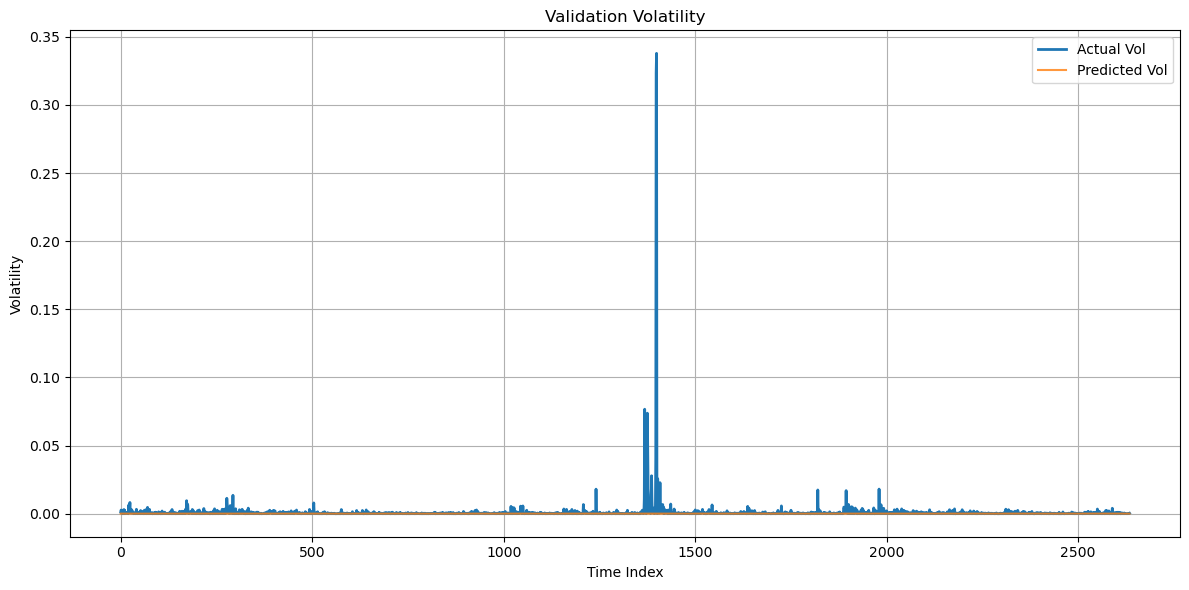

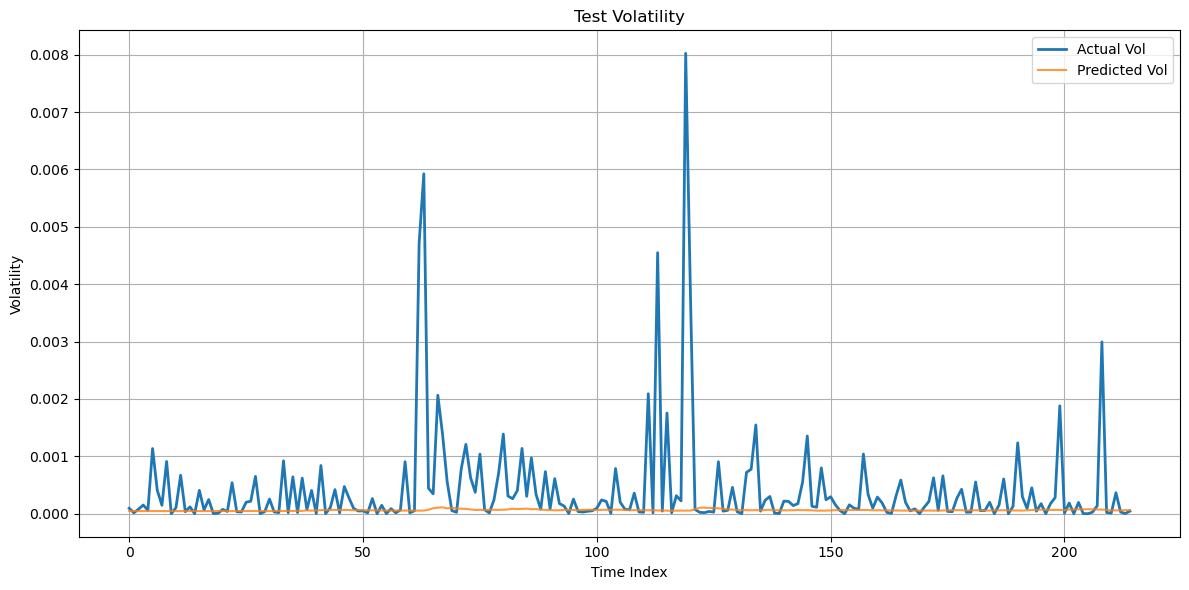

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_vol_time_series(y_true, y_pred, title="Volatility: Actual vs Predicted"):
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual Vol", linewidth=2)
    plt.plot(y_pred, label="Predicted Vol", alpha=0.8)

    plt.title(title)
    plt.xlabel("Time Index")
    plt.ylabel("Volatility")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_vol_time_series(vol_val_true, vol_val_pred, "Validation Volatility")
plot_vol_time_series(vol_test_true, vol_test_pred, "Test Volatility")

In [26]:
print("Correlation (Test):", np.corrcoef(vol_test_true, vol_test_pred)[0,1])

Correlation (Test): 0.0014413721869763264


In [27]:
print("Min log pred:", np.min(yhat_test))
print("Max log pred:", np.max(yhat_test))
print("Mean log pred:", np.mean(yhat_test))

Min log pred: -9.98782775855085
Max log pred: -9.108372369106208
Mean log pred: -9.704135332832657


In [28]:
print("Log-space correlation (test):",
      np.corrcoef(yte, yhat_test)[0,1])

Log-space correlation (test): 0.044167197492667856


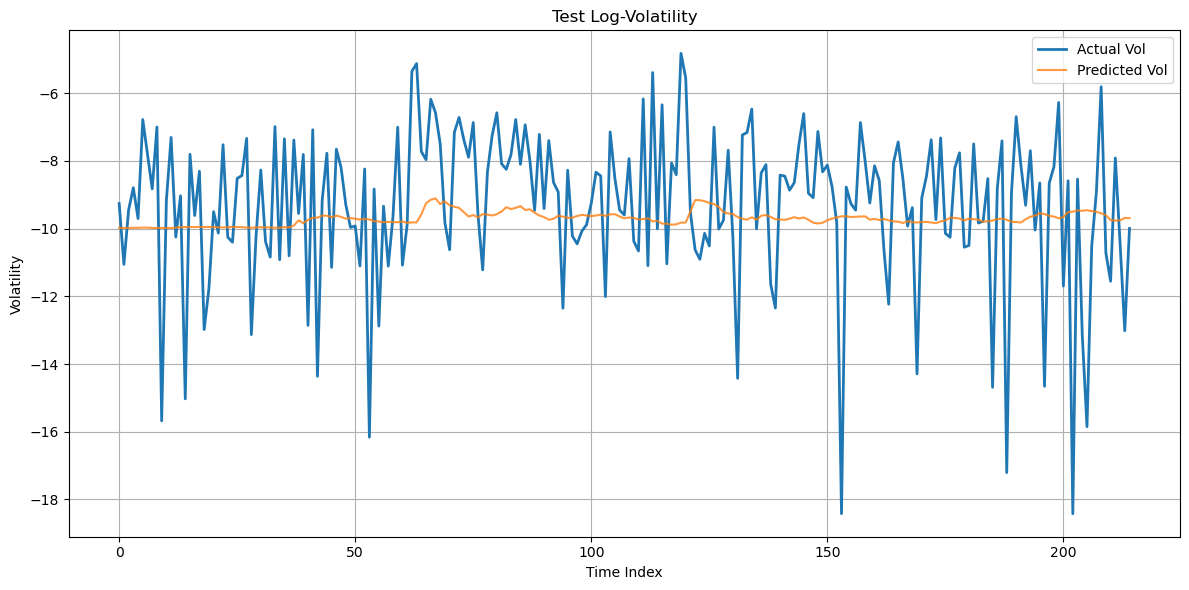

In [29]:
plot_vol_time_series(yte, yhat_test, "Test Log-Volatility")

In [30]:
baseline_pred = np.mean(ytr)  # unconditional mean log-vol
baseline_pred_array = np.full_like(yte, baseline_pred)

print("Baseline log correlation:",
      np.corrcoef(yte, baseline_pred_array)[0,1])

Baseline log correlation: 4.03083940769665e-16


In [35]:
from pathlib import Path
import numpy as np
import pandas as pd

def build_sequence_dataset_rv10(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
    epsilon: float = 1e-8,
):
    # --- Load macro monthly ---
    df_macro = pd.read_csv(macro_file, skiprows=[1]).rename(columns={"sasdate": "date"})
    df_macro["date"] = pd.to_datetime(df_macro["date"])
    df_macro = df_macro.set_index("date").sort_index()

    # Anti-leakage: month m available at month m+1
    df_macro.index = df_macro.index + pd.offsets.MonthBegin(1)

    # --- Load price (trading days) ---
    df_price = pd.read_csv(price_file, parse_dates=["Date"])
    df_price = df_price.set_index("Date")["Price"].sort_index().astype(float)

    # Align macro to trading days
    df_macro = df_macro.reindex(df_price.index, method="ffill")

    # Base frame
    df = df_macro[features].join(df_price.rename("Price")).dropna()

    # Daily log returns
    df["ret_1d"] = np.log(df["Price"]).diff()
    df = df.dropna()

    # Optional helpful inputs (vol persistence)
    df["abs_ret"] = df["ret_1d"].abs()
    df["ret_sq"]  = df["ret_1d"] ** 2
    df["rv_5_back"]  = df["ret_1d"].rolling(5).std()
    df["rv_10_back"] = df["ret_1d"].rolling(10).std()

    df = df.dropna()

    # -------- 10-DAY FORWARD REALIZED VARIANCE TARGET --------
    # RV10_t = sum_{i=1..10} r_{t+i}^2
    forward_rv10 = sum((df["ret_1d"].shift(-i) ** 2) for i in range(1, 11))
    df["rv10_target"] = np.log(forward_rv10 + epsilon)

    # Build y and drop columns not used as inputs
    y = df["rv10_target"]
    Xdf = df.drop(columns=["Price", "rv10_target"])

    # Remove rows where target is NaN (end of series)
    valid = y.notna()
    Xdf = Xdf.loc[valid]
    y = y.loc[valid]

    values = Xdf.values
    target = y.values

    # -------- Make sequences --------
    X_sequences, y_out = [], []
    for i in range(lookback, len(Xdf)):
        X_sequences.append(values[i - lookback:i])
        y_out.append(target[i])

    X_sequences = np.array(X_sequences)
    y_out = np.array(y_out)

    dates = Xdf.index[lookback:]

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_idx = dates <= train_end
    val_idx   = (dates > train_end) & (dates <= val_end)
    test_idx  = dates > val_end

    return (
        X_sequences[train_idx], y_out[train_idx],
        X_sequences[val_idx],   y_out[val_idx],
        X_sequences[test_idx],  y_out[test_idx],
    )

In [36]:
def build_sequence_dataset_rv30(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
    epsilon: float = 1e-8,
):
    df_macro = pd.read_csv(macro_file, skiprows=[1]).rename(columns={"sasdate": "date"})
    df_macro["date"] = pd.to_datetime(df_macro["date"])
    df_macro = df_macro.set_index("date").sort_index()
    df_macro.index = df_macro.index + pd.offsets.MonthBegin(1)

    df_price = pd.read_csv(price_file, parse_dates=["Date"])
    df_price = df_price.set_index("Date")["Price"].sort_index().astype(float)

    df_macro = df_macro.reindex(df_price.index, method="ffill")
    df = df_macro[features].join(df_price.rename("Price")).dropna()

    df["ret_1d"] = np.log(df["Price"]).diff()
    df = df.dropna()

    df["abs_ret"] = df["ret_1d"].abs()
    df["ret_sq"]  = df["ret_1d"] ** 2
    df["rv_5_back"]  = df["ret_1d"].rolling(5).std()
    df["rv_10_back"] = df["ret_1d"].rolling(10).std()
    df["rv_20_back"] = df["ret_1d"].rolling(20).std()

    df = df.dropna()

    # -------- 30-DAY FORWARD REALIZED VARIANCE TARGET --------
    forward_rv30 = sum((df["ret_1d"].shift(-i) ** 2) for i in range(1, 31))
    df["rv30_target"] = np.log(forward_rv30 + epsilon)

    y = df["rv30_target"]
    Xdf = df.drop(columns=["Price", "rv30_target"])

    valid = y.notna()
    Xdf = Xdf.loc[valid]
    y = y.loc[valid]

    values = Xdf.values
    target = y.values

    X_sequences, y_out = [], []
    for i in range(lookback, len(Xdf)):
        X_sequences.append(values[i - lookback:i])
        y_out.append(target[i])

    X_sequences = np.array(X_sequences)
    y_out = np.array(y_out)

    dates = Xdf.index[lookback:]

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_idx = dates <= train_end
    val_idx   = (dates > train_end) & (dates <= val_end)
    test_idx  = dates > val_end

    return (
        X_sequences[train_idx], y_out[train_idx],
        X_sequences[val_idx],   y_out[val_idx],
        X_sequences[test_idx],  y_out[test_idx],
    )

In [38]:
Xtr, ytr, Xva, yva, Xte, yte = build_sequence_dataset_rv10(
    MACRO_FILE, PRICE_FILE, FEATURES, lookback=30
)

print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)
print("Std y_val:", np.std(yva))

model = LSTMForecastModel(  # use the same hyperparams you used for vol
    epochs=80, hidden_size=128, num_layers=2, dropout=0.3,
    lr=5e-4, patience=15
)

model.fit(Xtr, ytr, Xva, yva)

yhat_test = model.predict(Xte)
print("Log-space correlation (test):", np.corrcoef(yte, yhat_test)[0,1])

Shapes: (7944, 30, 36) (2635, 30, 36) (206, 30, 36)
Std y_val: 0.9629014075462248
Using device: cpu
Epoch 1 | Val RMSE: 1.235615
Epoch 2 | Val RMSE: 0.852992
Epoch 3 | Val RMSE: 1.173509
Epoch 4 | Val RMSE: 1.080197
Epoch 5 | Val RMSE: 1.185963
Epoch 6 | Val RMSE: 0.783453
Epoch 7 | Val RMSE: 0.768808
Epoch 8 | Val RMSE: 0.832934
Epoch 9 | Val RMSE: 0.844928
Epoch 10 | Val RMSE: 0.797543
Epoch 11 | Val RMSE: 1.023357
Epoch 12 | Val RMSE: 1.124475
Epoch 13 | Val RMSE: 0.758771
Epoch 14 | Val RMSE: 0.841833
Epoch 15 | Val RMSE: 0.848636
Epoch 16 | Val RMSE: 0.955903
Epoch 17 | Val RMSE: 0.852930
Epoch 18 | Val RMSE: 1.029678
Epoch 19 | Val RMSE: 0.949393
Epoch 20 | Val RMSE: 0.914745
Epoch 21 | Val RMSE: 0.978777
Epoch 22 | Val RMSE: 0.815818
Epoch 23 | Val RMSE: 0.896386
Epoch 24 | Val RMSE: 0.845407
Epoch 25 | Val RMSE: 0.847616
Epoch 26 | Val RMSE: 0.933926
Epoch 27 | Val RMSE: 0.896889
Epoch 28 | Val RMSE: 0.971542
Early stopping triggered
Log-space correlation (test): -0.05595196600

In [39]:
Xtr, ytr, Xva, yva, Xte, yte = build_sequence_dataset_rv30(
    MACRO_FILE, PRICE_FILE, FEATURES, lookback=30
)

print("Shapes:", Xtr.shape, Xva.shape, Xte.shape)
print("Std y_val:", np.std(yva))

model = LSTMForecastModel(
    epochs=80, hidden_size=128, num_layers=2, dropout=0.3,
    lr=5e-4, patience=15
)

model.fit(Xtr, ytr, Xva, yva)

yhat_test = model.predict(Xte)
print("Log-space correlation (test):", np.corrcoef(yte, yhat_test)[0,1])

Shapes: (7934, 30, 37) (2635, 30, 37) (186, 30, 37)
Std y_val: 0.8812013887081748
Using device: cpu
Epoch 1 | Val RMSE: 1.234916
Epoch 2 | Val RMSE: 1.284810
Epoch 3 | Val RMSE: 1.100809
Epoch 4 | Val RMSE: 1.220044
Epoch 5 | Val RMSE: 0.844415
Epoch 6 | Val RMSE: 0.876950
Epoch 7 | Val RMSE: 0.753918
Epoch 8 | Val RMSE: 0.898112
Epoch 9 | Val RMSE: 0.873564
Epoch 10 | Val RMSE: 0.878780
Epoch 11 | Val RMSE: 0.807707
Epoch 12 | Val RMSE: 0.816815
Epoch 13 | Val RMSE: 0.972577
Epoch 14 | Val RMSE: 0.944507
Epoch 15 | Val RMSE: 1.072707
Epoch 16 | Val RMSE: 0.854447
Epoch 17 | Val RMSE: 0.940726
Epoch 18 | Val RMSE: 0.960023
Epoch 19 | Val RMSE: 0.856687
Epoch 20 | Val RMSE: 0.825858
Epoch 21 | Val RMSE: 0.811812
Epoch 22 | Val RMSE: 0.869386
Early stopping triggered
Log-space correlation (test): -0.08804390678724279


In [ ]:
# naive persistence baseline
yhat_baseline = np.roll(yte, 1)
yhat_baseline[0] = yhat_baseline[1]

print("Baseline correlation:", np.corrcoef(yte, yhat_baseline)[0,1])

Baseline correlation: 0.9817522340994996


: 